In [27]:
# Imports

import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras.datasets import cifar10 # type: ignore
from tensorflow.keras.datasets import fashion_mnist # type: ignore
from keras.metrics import R2Score

### Questão 1

Implemente uma rede perceptron de múltiplas camadas e utilize-a para aproximar as funções abaixo.  

a. f(x) = log10(x), onde 1 ≤ x ≤ 10

b. f(x) = 10x^5 + 5x^4 + 2x^3 – 0.5x^2 + 3x + 2, onde 0 ≤ x ≤ 5

Para cada função a ser aproximada, gere um conjunto de treinamento e um conjunto de testes. 

Nesses conjuntos, cada amostra deve ser representada da seguinte forma: x é a entrada e f(x) é a saída desejada - rótulo. Treine um perceptron de múltiplas camadas para que ele aprenda a aproximar a função a partir do conjunto de treinamento, e vá testando com o conjunto de validação.  

Apresente os gráficos das funções reais vs. funções aproximadas e as curvas de erro de treinamento e validação.

#### Item a)

In [28]:
# Data

f = lambda x: np.log10(x)
X = np.linspace(1, 10, 10000).reshape(-1, 1)
y = f(X)

X_max = max(X)
X_normalized = X/X_max
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_normalized, y, test_size=0.35, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

In [29]:
# Model

input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(100, activation="relu")(input_)
hidden2 = keras.layers.Dense(100, activation="relu")(hidden1)
hidden3 = keras.layers.Dense(100, activation="relu")(hidden2)
output = keras.layers.Dense(1, dtype="float64")(hidden3)

model = keras.Model(inputs=[input_], outputs=[output])
model.compile(loss="mse", optimizer="adam")
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,501 (80.48 KB)

 Trainable params: 20,501 (80.48 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Train

history = model.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid))

# Prediction

y_pred = model.predict(X_test)

Epoch 1/50


 55/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1919   

2025-08-23 00:54:27.265257: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:54:27.301890: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0283 - val_loss: 0.0044
Epoch 2/50
 62/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0037

2025-08-23 00:54:27.728360: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:54:27.734441: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0035 - val_loss: 0.0028
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0013 - val_loss: 3.2149e-04
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5700e-04 - val_loss: 6.6598e-05
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.4223e-05 - val_loss: 2.6629e-05
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ -1s -7279us/step - loss: 2.0986e-05 - val_loss: 1.6444e-05
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3904e-05 - val_loss: 1.5641e-05
Epoch 8/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0608e-05 - val_loss: 8.7913e-06
Epoch 9/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.5491e-06 - val_loss: 8.2611e-06
Epoch 10/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.0117e-06 - val_loss: 6.9835e-06
Epoch 11/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.6459e-06 - val_loss: 1.3709e-05
Epoch 12/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.3675e-06 - va

2025-08-23 00:54:45.397304: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:54:45.400287: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:54:45.501531: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:54:45.504073: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


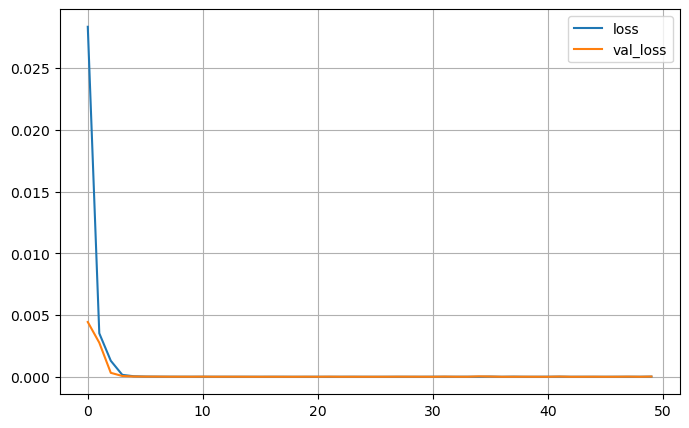

In [31]:
# Training Metrics

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

tf.Tensor(0.9996848, shape=(), dtype=float32)


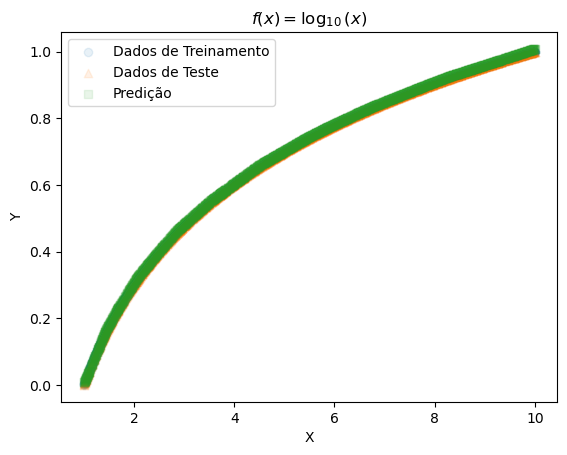

In [32]:
# Metrics

metric = keras.metrics.R2Score()
metric.update_state(y_test, y_pred)
result = metric.result()
print(result)

X_train_plot = X_train*X_max
X_test_plot = X_test*X_max

plt.figure()
plt.scatter(X_train_plot, y_train, alpha=0.1, label="Dados de Treinamento")
plt.scatter(X_test_plot, y_test, marker="^", alpha=0.1, label="Dados de Teste")
plt.scatter(X_test_plot, y_pred, marker="s", alpha=0.1, label="Predição")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title(r"$f(x) = \log _{10}(x)$");


#### Item b)

In [33]:
# Data

f = lambda x: 10*x**5 + 5*x**4 + 2*x**3 - 0.5*x**2 + 3*x + 2
X = np.linspace(0, 5, 10000).reshape(-1,1)
y = f(X)

X_max = max(X)
X_normalized = X/X_max
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_normalized, y, test_size=0.35, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

In [34]:
# Model

input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(100, activation="relu")(input_)
hidden2 = keras.layers.Dense(100, activation="relu")(hidden1)
hidden3 = keras.layers.Dense(100, activation="relu")(hidden2)
output = keras.layers.Dense(1, dtype="float64")(hidden3)

model = keras.Model(inputs=[input_], outputs=[output])
model.compile(loss="mse", optimizer="adam")
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,501 (80.48 KB)

 Trainable params: 20,501 (80.48 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Train

history = model.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid))

# Prediction

y_pred = model.predict(X_test)

Epoch 1/100
 61/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 113302816.0000  

2025-08-23 00:54:46.878062: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:54:46.911962: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 113237952.0000 - val_loss: 89873920.0000
Epoch 2/100
 29/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 111272680.0000 

2025-08-23 00:54:47.290686: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:54:47.296748: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 71093416.0000 - val_loss: 52058116.0000
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 53139728.0000 - val_loss: 45174472.0000
Epoch 4/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 44741640.0000 - val_loss: 36210188.0000
Epoch 5/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 34974232.0000 - val_loss: 26966060.0000
Epoch 6/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 25159790.0000 - val_loss: 18257152.0000
Epoch 7/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16490398.0000 - val_loss: 11533697.0000
Epoch 8/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9961789.0000 - val_loss: 6754257.5000
Epoch 9/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5938447.5000 - val_loss: 3998722.0000
Epoch 10/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3667761.5000 - val_loss: 2494664.7500
Epoch 11/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2405621.2500 - val_loss: 1642967.3750
Epoch 12

2025-08-23 00:55:24.850194: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:55:24.852821: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:55:24.963309: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:55:24.966334: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


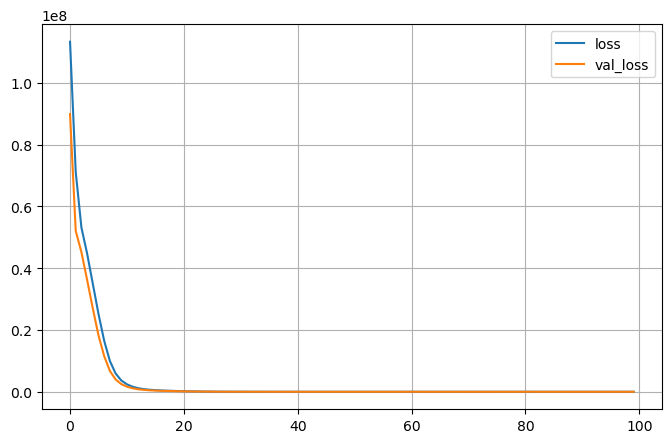

In [36]:
# Training Metrics

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

tf.Tensor(0.9999997, shape=(), dtype=float32)


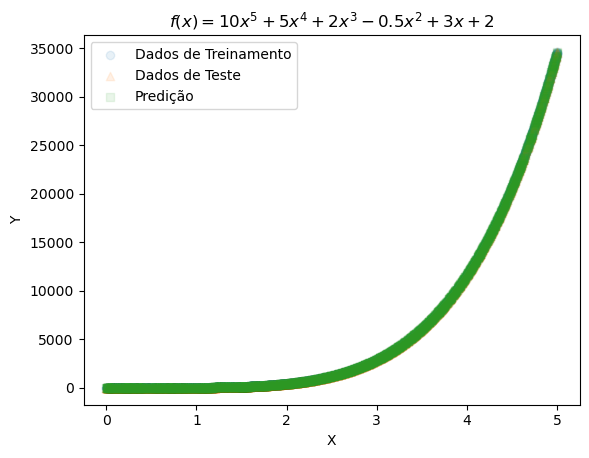

In [48]:
# Metrics

metric = keras.metrics.R2Score()
metric.update_state(y_test, y_pred)
result = metric.result()
print(result)

X_train_plot = X_train*X_max
X_test_plot = X_test*X_max

plt.figure()
plt.scatter(X_train_plot, y_train, alpha=0.1, label="Dados de Treinamento")
plt.scatter(X_test_plot, y_test, marker="^", alpha=0.1, label="Dados de Teste")
plt.scatter(X_test_plot, y_pred, marker="s", alpha=0.1, label="Predição")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title(r"$f(x) = 10x^5 + 5x^4 + 2x^3 - 0.5x^2 + 3x + 2$");

### Questão 2

### Questão 3

In [38]:
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()

print("CIFAR-10 Training data shape:", X_train_cifar.shape)
print("CIFAR-10 Training labels shape:", y_train_cifar.shape)
print("CIFAR-10 Test data shape:", X_test_cifar.shape)
print("CIFAR-10 Test labels shape:", y_test_cifar.shape)

CIFAR-10 Training data shape: (50000, 32, 32, 3)
CIFAR-10 Training labels shape: (50000, 1)
CIFAR-10 Test data shape: (10000, 32, 32, 3)
CIFAR-10 Test labels shape: (10000, 1)


### Questão 4

In [39]:
(X_train_fashion, y_train_fashion), (X_test_fashion, y_test_fashion) = fashion_mnist.load_data()

print("Fashion-MNIST Training data shape:", X_train_fashion.shape)
print("Fashion-MNIST Training labels shape:", y_train_fashion.shape)
print("Fashion-MNIST Test data shape:", X_test_fashion.shape)
print("Fashion-MNIST Test labels shape:", y_test_fashion.shape)

Fashion-MNIST Training data shape: (60000, 28, 28)
Fashion-MNIST Training labels shape: (60000,)
Fashion-MNIST Test data shape: (10000, 28, 28)
Fashion-MNIST Test labels shape: (10000,)


### Questão 5